Se importan las librerías básicas.

In [ ]:
!pip install spatialdata
!pip install spatialdata_plot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.8/114.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 80.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


La siguiente celda sirve específicamente si se tienen todos los archivos, con el nombre original en una carpeta de drive. En caso contrario, es necesario importarlos manualmente.

In [ ]:
from google.colab import drive
import sys
import os
import spatialdata as sd
import spatialdata_plot
import pandas as pd

# Montar el Drive
drive.mount('/content/drive')

# Definir el nombre exacto de la carpeta
NOMBRE_CARPETA = 'TFM Eloy de la Infanta'
ruta_raiz = f'/content/drive/MyDrive/{NOMBRE_CARPETA}'

# Control de errores por si hay problemas el acceso directo
if not os.path.exists(ruta_raiz):
    raise FileNotFoundError(
        f" No se encuentra la carpeta '{NOMBRE_CARPETA}' en tu 'Mi Unidad'.\n"
        "Recuerda ir a 'Compartido conmigo', hacer clic derecho en la carpeta y "
        "seleccionar 'Organizar > Añadir acceso directo' hacia 'Mi unidad'."
    )

# Añadir la ruta a Python para poder importar el archivo .py
sys.path.append(ruta_raiz)
from Codigo_TFM_final import *

# Cargar el archivo .zarr
ruta_zarr = os.path.join(ruta_raiz, 'human_ROI1.zarr')
sdata = sd.read_zarr(ruta_zarr)
print("Objeto de SpatialData con la imagen de ejemplo cargado correctamente.")

ruta_tabla_completa = os.path.join(ruta_raiz, 'Pheno_table_both_phases.csv')
tabla_completa = pd.read_csv(ruta_tabla_completa)
print("Tabla de fenotipado completa cargada correctamente.")

ruta_tabla_GT = os.path.join(ruta_raiz, 'Pheno_GT_both_phases.csv')
tabla_GT = pd.read_csv(ruta_tabla_GT)
print("Tabla de fenotipado de ground truth cargada correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Objeto de SpatialData con la imagen de ejemplo cargado correctamente.
Tabla de fenotipado completa cargada correctamente.
Tabla de fenotipado de ground truth cargada correctamente.


Se muestra la estructura del objeto SpatialData cargado

In [ ]:
print(sdata)

SpatialData object, with associated Zarr store: /content/drive/MyDrive/TFM Eloy de la Infanta/human_ROI1.zarr
├── Images
│     └── 'ROI1_complete': DataTree[cyx] (31, 10214, 6261), (31, 5107, 3130), (31, 2553, 1565), (31, 1276, 782), (31, 638, 391)
├── Shapes
│     └── 'boundaries_joan': GeoDataFrame shape: (15573, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (15573, 109)
with coordinate systems:
    ▸ 'global', with elements:
        ROI1_complete (Images), boundaries_joan (Shapes)


Se recorta la imagen, para facilitar la ejecución, especialmente desde Colab

In [ ]:
cropped_roi = sdata.query.bounding_box(
        axes=('x', 'y'),
        min_coordinate=[0, 0],
        max_coordinate=[2000, 2000],
        target_coordinate_system='global'
        )
del sdata

Se muestra la imagen recortada

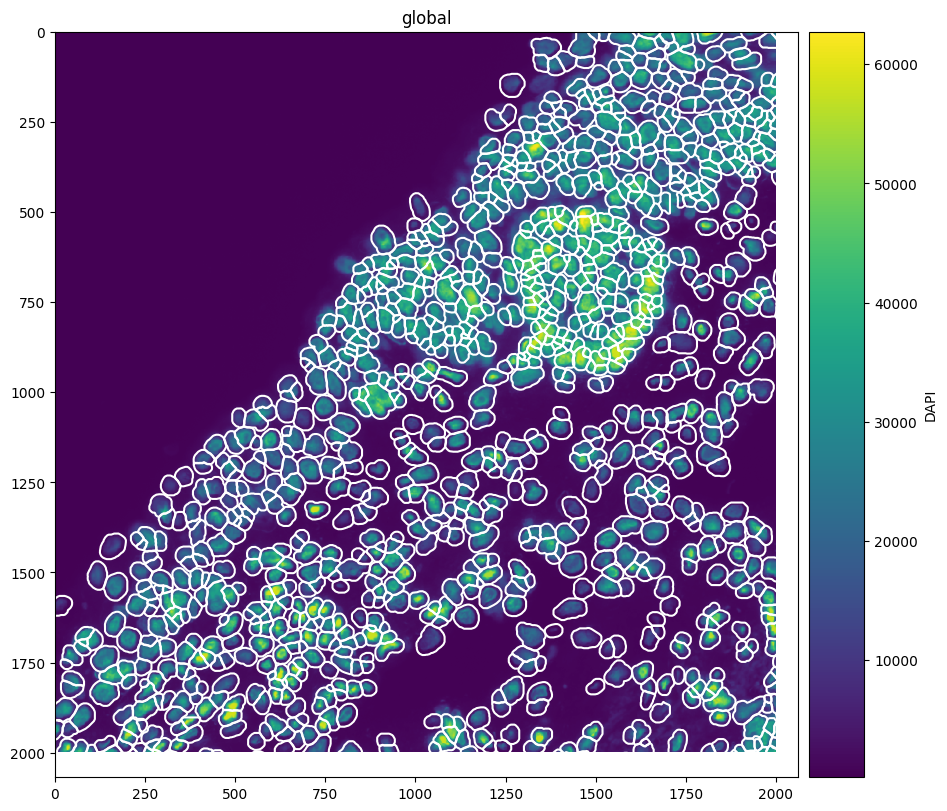

In [ ]:
cropped_roi.pl.render_images('ROI1_complete', cmap="viridis", channel=["DAPI"])\
        .pl.render_shapes(
            "boundaries_joan",
            fill_alpha=0,
            outline_color="white",
            outline_width=1.5
        ).pl.show(figsize = (8,8))

Se ejecuta todo el pipeline completo, visualizándose los distintos pasos.

In [ ]:
sdata = phenotype_full_pipeline(
                    pheno_both = tabla_completa, #Modificar aquí si se quiere usar la otra tabla de fenotipado
                    sdata = cropped_roi,
                    IMAGE_KEY = None,
                    CELLS_KEY = None,
                    NUCLEUS_KEY = "nucleus",
                    TABLE_KEY = "table",
                    SUBCELLULAR_REGIONS_KEY = "subcellular_regions",
                    SUBCELLULAR_REGIONS_TABLE = "table_subcellular_regions",
                    LINEAGE_PHENOTYPE_COLUMN = "lineage_phenotype",
                    FINAL_PHENOTYPE_COLUMN = "final_phenotype",
                    global_positive_strategy="rightmost",
                    SAVE_ROUTE = None, # Si se desea guardar el resultado
                    channels = ['CD8a','CD68','Ki_67','CD163','CD3','FoxP3','INSM1sc-271408','HLA_DR','CD4','CD11b','Pan_Cytokeratin','Actin','CD31'],
                    places_map = {
                            "CD8_T_cell" : "neutral",
                            "CD4_T_cell" : "neutral",
                            "T_cell" : "neutral",
                            "T_double" : "neutral",
                            "Endothelial" : "neutral",
                            "Fibroblast" : "neutral",
                            "M1_Macrophage" : "neutral",
                            "M2_Macrophage" : "neutral",
                            "Monocyte" : "neutral",
                            "Tumour" : "neutral"},
                    data_is_logarithmic = False,
                    n_jobs = 1,
                    clipping_percentile = 99,
                    verbose = True
                    )

Output hidden; open in https://colab.research.google.com to view.